## QAOA for Low Autocorrelation Binary Sequences (LABS) problem

Low Autocorrelation Binary Sequences (LABS) problems is to find a spin sequence  with $s_i \in \{+1,-1\}$ of length $N$ with small off-peak autocorrelations.  The off-peak autocorrelations are defined as

$$
C_k(S) = \sum_{i=1}^{N-k} s_i\,s_{i+k} \qquad (k=1,\dots,N-1)
$$

and the LABS energy is defined as their sum of squares

$$
E(S) = \sum_{k=1}^{N-1} C_k(S)^2.
$$

The goal is to find sequences that minimize this energy, which corresponds to finding binary sequences with the lowest possible autocorrelation — a fundamental problem in signal processing and combinatorial optimization. 

In [2]:
import itertools
from collections.abc import Sequence

import numpy as np


def labs_energy(s: Sequence[int]) -> float:
    n = len(s)
    e_labs = 0
    for k in range(1, n):
        c_k = 0
        for i in range(1, n - k + 1):
            c_k += s[i - 1] * s[i + k - 1]
        e_labs += c_k**2
    return e_labs

### Choose N

The brute-force baseline for solving this problem is $O(2^N)$ which is practically infeasible for $N > 100$. The goal of this tutorial is to show how Quantum Approximation Optimization Algorithms (QAOA) can be applied to solve this problem. We will use small N for the tutorial for the ease of illustration, but the same approach can be applied to large N problems.

In [3]:
N = 11  # this corresponds to 2**11=2048 states

### Spin to bits conventions

In some cases it is convenient to represent the spin sequence $s_i \in \{+1,-1\}$ as a bits array $x \in \{0,1\}^N$. There is a one-to-one mapping between bits array and spins $s_i \in \{+1,-1\}$.

- $x_i = 0$ for spin $s_i = +1$
- $x_i = 1$ for spin $s_i = -1$

This is equivalent to $x_i = \frac{1 - s_i}{2}$ or, in the other direction, $s_i = 1 - 2x_i$.

In [4]:
def labs_energy_from_bitarray(x: np.ndarray) -> float:
    return labs_energy(1 - 2 * x)

### Exact baseline (small N)

For small $N$, we can brute-force all $2^N$ bit arrays to compute the true ground state energy and ground states. This is a great sanity check before running QAOA. Also average energy over all bit arrays, random sampling, is a good baseline to beat.

We see 4 ground states which are the symmetric, left to right and 0 to 1 flipped versions of each other due to the symmetries of the LABS energy.


In [5]:
from collections import defaultdict


average_energy_random_sampling = 0
energy_states = defaultdict(list)
min_energy = float("inf")
for bs in range(2**N):  # scan all bitstrings
    bit_array = np.array(list(map(int, f"{bs:0{N}b}")))
    energy = labs_energy_from_bitarray(bit_array)
    energy_states[energy].append(bit_array.tolist())
    average_energy_random_sampling += energy
    min_energy = min(min_energy, energy)
average_energy_random_sampling /= 2**N
print(f"Ground state energy: {min_energy}")
print(
    f"Ground states: Count: {len(energy_states[min_energy])}. States: {energy_states[min_energy]}. Energy: {min_energy}"
)
print(f"Average energy from random sampling: {average_energy_random_sampling}")

Ground state energy: 5
Ground states: Count: 4. States: [[0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1], [0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1], [1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0], [1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0]]. Energy: 5
Average energy from random sampling: 55.0


### Histogram of energies

We can see that the histogram of energies of the LABS problem are spread out thus makeing it hard to find the ground states.

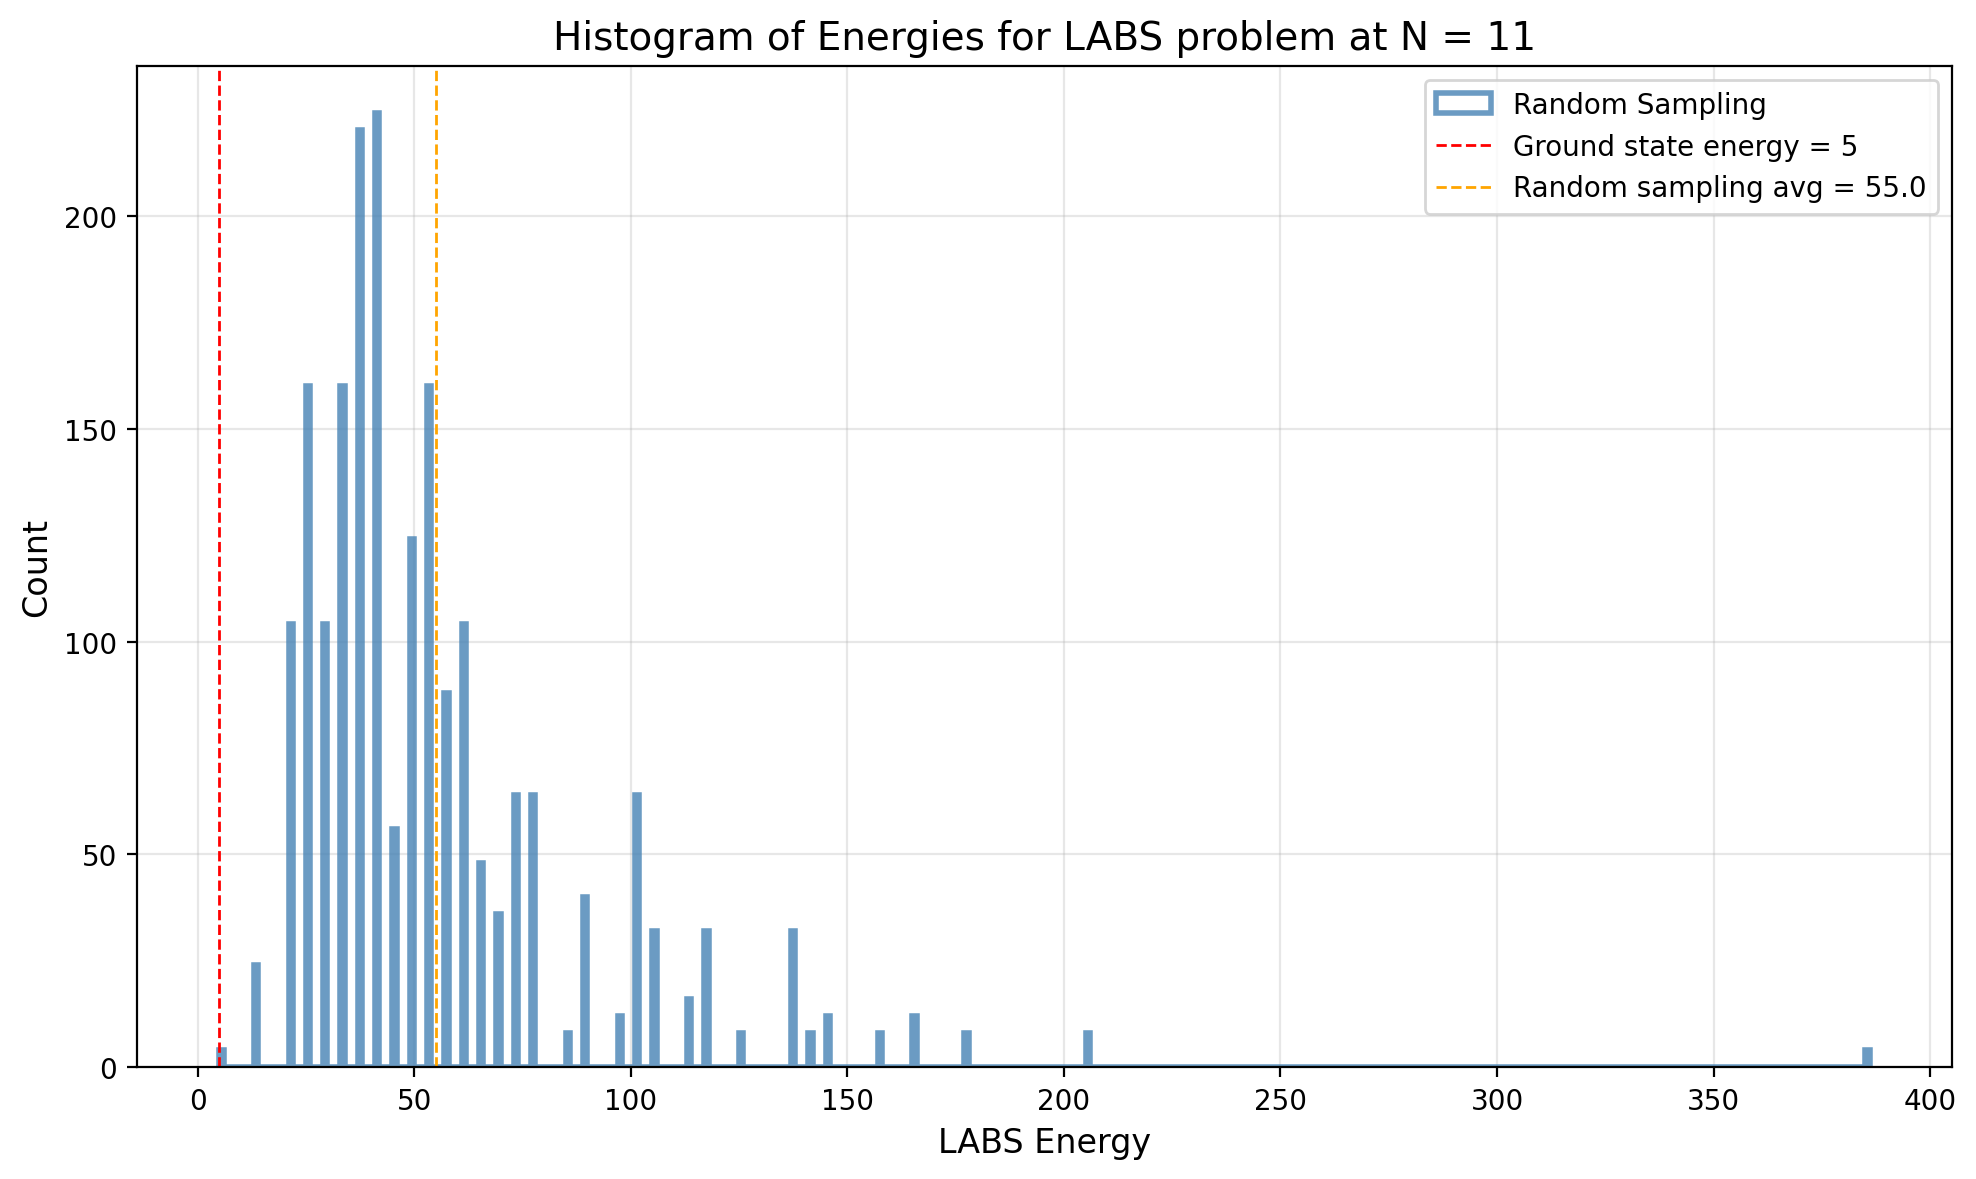

In [6]:
import matplotlib.pyplot as plt


# Create histogram of energies
random_sampling_energies = []
for energy_value, states in energy_states.items():
    random_sampling_energies.extend([energy_value] * len(states))

plt.figure(figsize=(10, 6), dpi=200)

bins = range(int(min(random_sampling_energies)), int(max(random_sampling_energies)) + 2)
plt.hist(
    random_sampling_energies,
    bins=bins,
    histtype="step",
    alpha=0.8,
    color="steelblue",
    edgecolor="steelblue",
    linewidth=2,
    label="Random Sampling",
)
plt.axvline(
    x=min_energy,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Ground state energy = {min_energy}",
)
plt.axvline(
    x=average_energy_random_sampling,
    color="orange",
    linestyle="--",
    linewidth=1,
    label=f"Random sampling avg = {average_energy_random_sampling:.1f}",
)
plt.xlabel("LABS Energy", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title(f"Histogram of Energies for LABS problem at N = {N}", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Build the LABS cost Hamiltonian (Pauli-Z form)

To solve the LABS problem using Quantum Approximation Optimization Algorithms (QAOA), we need to build the cost Hamiltonian in the quantum Pauli-Z form: represented as sums of different products of $Z_i \otimes Z_{j}$ and $ Z_i \otimes Z_{j} \otimes Z_{k} \otimes Z_{l}$.

We can use the open source functions provided by JP Morgan's QOKit found at https://github.com/jpmorganchase/QOKit to build the cost Hamiltonian in Qiskit's `SparsePauliOp` format.

In [7]:
from qiskit.quantum_info import SparsePauliOp


def get_terms_and_offset(n: int):
    # return the indices of Pauli Zs in products
    all_terms = []
    offset = 0
    # sum_{k=1}^{N-1} (\sum_{i=1}^{N-k} s_i s_{i+k})^2
    for k in range(1, n):
        offset += n - k  # quadratic terms go to one
        for i, j in itertools.combinations(range(1, n - k + 1), 2):
            # -1 because we index from 1
            # Drop duplicate terms, e.g. Z1Z2Z2Z3 should be just Z1Z3
            if i + k == j:
                all_terms.append((2, tuple(sorted((i - 1, j + k - 1)))))
            else:
                all_terms.append((4, tuple(sorted((i - 1, i + k - 1, j - 1, j + k - 1)))))
    return list(set(all_terms)), offset


terms, offset = get_terms_and_offset(N)
pauli_list = []
for num_components, edge in terms:
    weight = num_components
    if num_components == 2:
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    elif num_components == 4:
        pauli_list.append(("ZZZZ", [edge[0], edge[1], edge[2], edge[3]], weight))
cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, N)

### Build the QAOA circuit

We use Qiskit’s `QAOAAnsatz` to build a parameterized QAOA circuit for our LABS cost Hamiltonian, then transpile it to a simple gate basis.


In [8]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator


p = 1  # p = 100 was tried too, it runs much slower but outputs the exact ground state energy during sampling
# Build a parameterized QAOA circuit.
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=p)
pm = generate_preset_pass_manager(
    optimization_level=3, backend=AerSimulator(), routing_method="none"
)
# Transpile to a simple basis (useful if you target specific backends).
transpiled_circuit = pm.run(circuit)
assert transpiled_circuit.num_parameters == 2 * p
print("Gate counts:", transpiled_circuit.count_ops())

Gate counts: OrderedDict([('cx', 412), ('rz', 70), ('rzz', 25), ('h', 11), ('rx', 11)])


### Cost Hamiltonian Estimation 

To estimate the energy of the QAOA circuit, we can use the BlueQubit estimator backend which supports state of the art CPU or GPU statevector simulators both in cloud or hybrid setups.

In [9]:
import time

from bluequbit import BlueQubitEstimatorV2


device = "cpu"  # can be "gpu" for devices with GPUs
estimator = BlueQubitEstimatorV2(
    options={
        "backend_options": {
            "execution_mode": "local",  # can be "cloud" too
        },
        "run_options": {"device": device},
    }
)


def cost_func_estimator(params):
    # transform the observable defined on virtual qubits to
    pub = (transpiled_circuit, cost_hamiltonian, params)
    job = estimator.run([pub])

    job_result = job.result()[0]
    cost = job_result.data.evs
    objective_func_vals.append(cost)
    iteration_timestamps.append(time.time())
    iteration_no = len(objective_func_vals)
    if iteration_no % 50 == 0:
        print(
            f"Iteration no {iteration_no}, cost {cost}, time per iteration {iteration_timestamps[-1] - iteration_timestamps[-2]} seconds,"
        )

    return cost

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.3b1 of BlueQubit Python SDK is being used.


### Find the QAOA optimized circuit

We can use the `scipy.optimize.minimize` function to find the QAOA optimized circuit accroos multiple trials with random initializations of  parameters.

In [10]:
import numpy as np
from scipy.optimize import minimize


n_trials = 4
rng = np.random.default_rng(42)
best_params = None
best_cost = float("inf")
best_trial = None

objective_func_vals_all = [[] for _ in range(n_trials)]
iteration_timestamps_all = [[] for _ in range(n_trials)]


for trial_no in range(n_trials):
    # Sample from reasonable QAOA ranges
    objective_func_vals = []
    iteration_timestamps = [time.time()]
    gamma_init = rng.uniform(-np.pi, np.pi, p)
    beta_init = rng.uniform(-np.pi, np.pi, p)
    init_params = list(beta_init) + list(gamma_init)

    result = minimize(cost_func_estimator, init_params, method="COBYLA", options={"maxiter": 500})
    objective_func_vals_all[trial_no] = objective_func_vals
    iteration_timestamps_all[trial_no] = iteration_timestamps
    if result.fun < best_cost:
        best_trial = trial_no
        best_cost = result.fun
        best_params = result.x
    print(f"Finished trial number {trial_no + 1}")

optimized_circuit = transpiled_circuit.assign_parameters(best_params)

[BQ-PYTHON-SDK][INFO] - Total memory of the host: 31 GB
[BQ-PYTHON-SDK][INFO] - Maximum number of qubits for statevector simulation supported on this host's CPU: 31
Iteration no 50, cost -5.573109354020971, time per iteration 0.09483814239501953 seconds,
Iteration no 100, cost -5.957215777755209, time per iteration 0.09630727767944336 seconds,
Iteration no 150, cost -6.273588918500764, time per iteration 0.09457945823669434 seconds,
Iteration no 200, cost -6.525818698344665, time per iteration 0.09579110145568848 seconds,
Iteration no 250, cost -6.716742421079289, time per iteration 0.10340738296508789 seconds,
Iteration no 300, cost -6.851418322719766, time per iteration 0.12430262565612793 seconds,
Iteration no 350, cost -6.945968046406108, time per iteration 0.09900498390197754 seconds,
Iteration no 400, cost -7.018418067837047, time per iteration 0.10229206085205078 seconds,
Iteration no 450, cost -7.029847827478989, time per iteration 0.1245872974395752 seconds,
Iteration no 500, 

### Plot the objective function values during the optimization

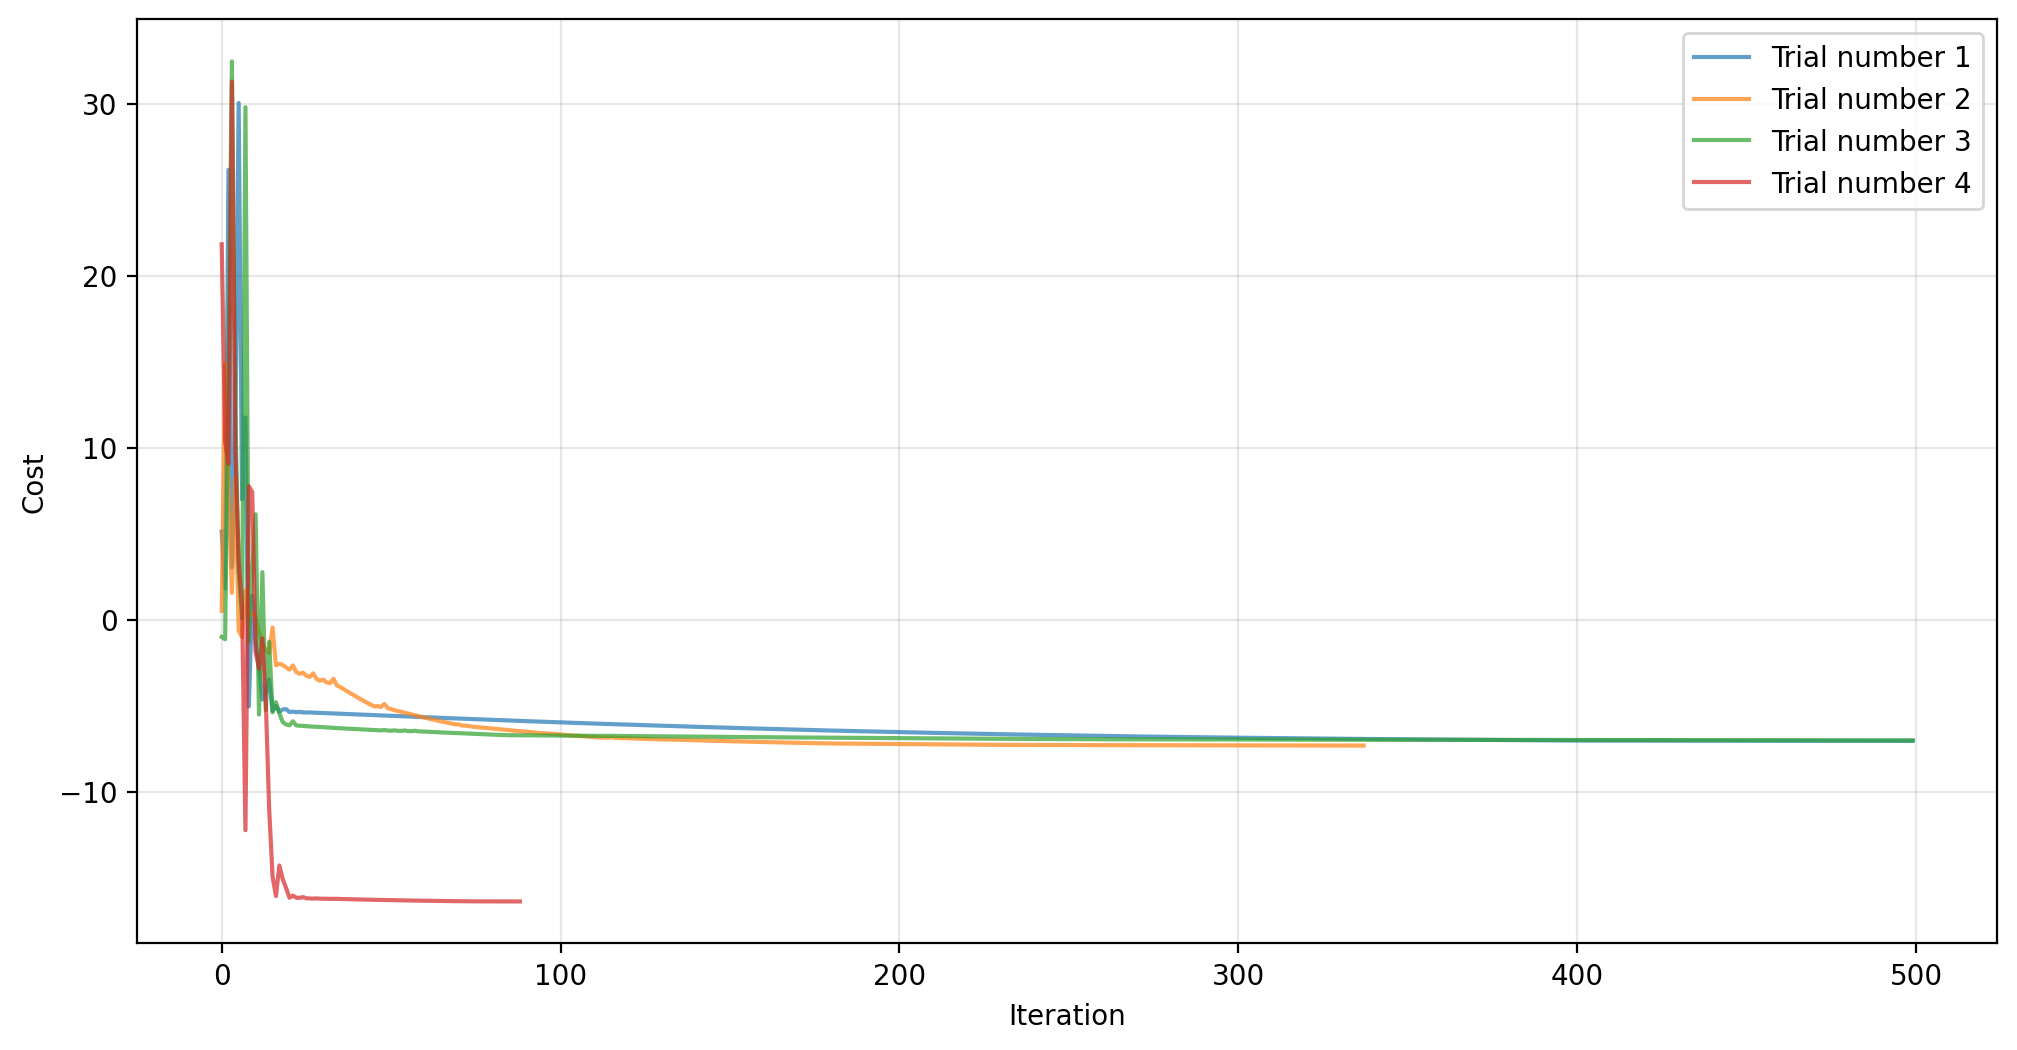

In [11]:
plt.figure(figsize=(12, 6), dpi=200)
for trial_no in range(n_trials):
    plt.plot(
        objective_func_vals_all[trial_no],
        alpha=0.7,
        label=f"Trial number {trial_no + 1}",
    )
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.show()

### Sampling the QAOA optimized circuit using BlueQubitSamplerV2 and interpreting the results

After optimization, we sample the optimized QAOA circuit to obtain candidate bitstrings. We can see that ground state energy state was sampled. Then we calculate the average energy of the sampled bitstrings. Which turns out to be about 30% lower than the random sampling baseline.

In [12]:
from bluequbit import BlueQubitSamplerV2


shots = 1024
sampler = BlueQubitSamplerV2(
    backend_options={
        "execution_mode": "local",
    }
)
job = sampler.run([(optimized_circuit,)], shots=shots)
counts_bin = job.result()[
    0
].data.meas.get_counts()  # returns a dictionary of bitstrings and their counts

average_energy_qaoa_sampling = 0
min_energy_qaoa_sampling = float("inf")
num_shots = 0
for k, v in counts_bin.items():
    bit_array = np.array(list(map(int, k)))  # convert bitstring to bitarray
    average_energy_qaoa_sampling += v * labs_energy_from_bitarray(bit_array)
    num_shots += v
    min_energy_qaoa_sampling = min(min_energy_qaoa_sampling, labs_energy_from_bitarray(bit_array))

assert num_shots == shots
average_energy_qaoa_sampling /= num_shots
percent_improvement = (
    (average_energy_random_sampling - average_energy_qaoa_sampling)
    / average_energy_random_sampling
    * 100
)
print(
    f"Min energy from QAOA sampling: {min_energy_qaoa_sampling} vs min energy from exact brute-force: {min_energy}"
)
print(
    f"Average energy from QAOA sampling: {average_energy_qaoa_sampling:.1f}, which is {percent_improvement:.2f}% improvement compared to average energy from random sampling: {average_energy_random_sampling:.1f}"
)

[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.3b1 of BlueQubit Python SDK is being used.
: probabilities do not sum to 1 (0.9999999784489546): renormalizing


Min energy from QAOA sampling: 5 vs min energy from exact brute-force: 5
Average energy from QAOA sampling: 40.6, which is 26.20% improvement compared to average energy from random sampling: 55.0



### Create histogram of energies from QAOA sampling

QAOA sampled data is plotted in the histogram below. We can see that the QAOA sampling is more concentrated around the ground state energy.

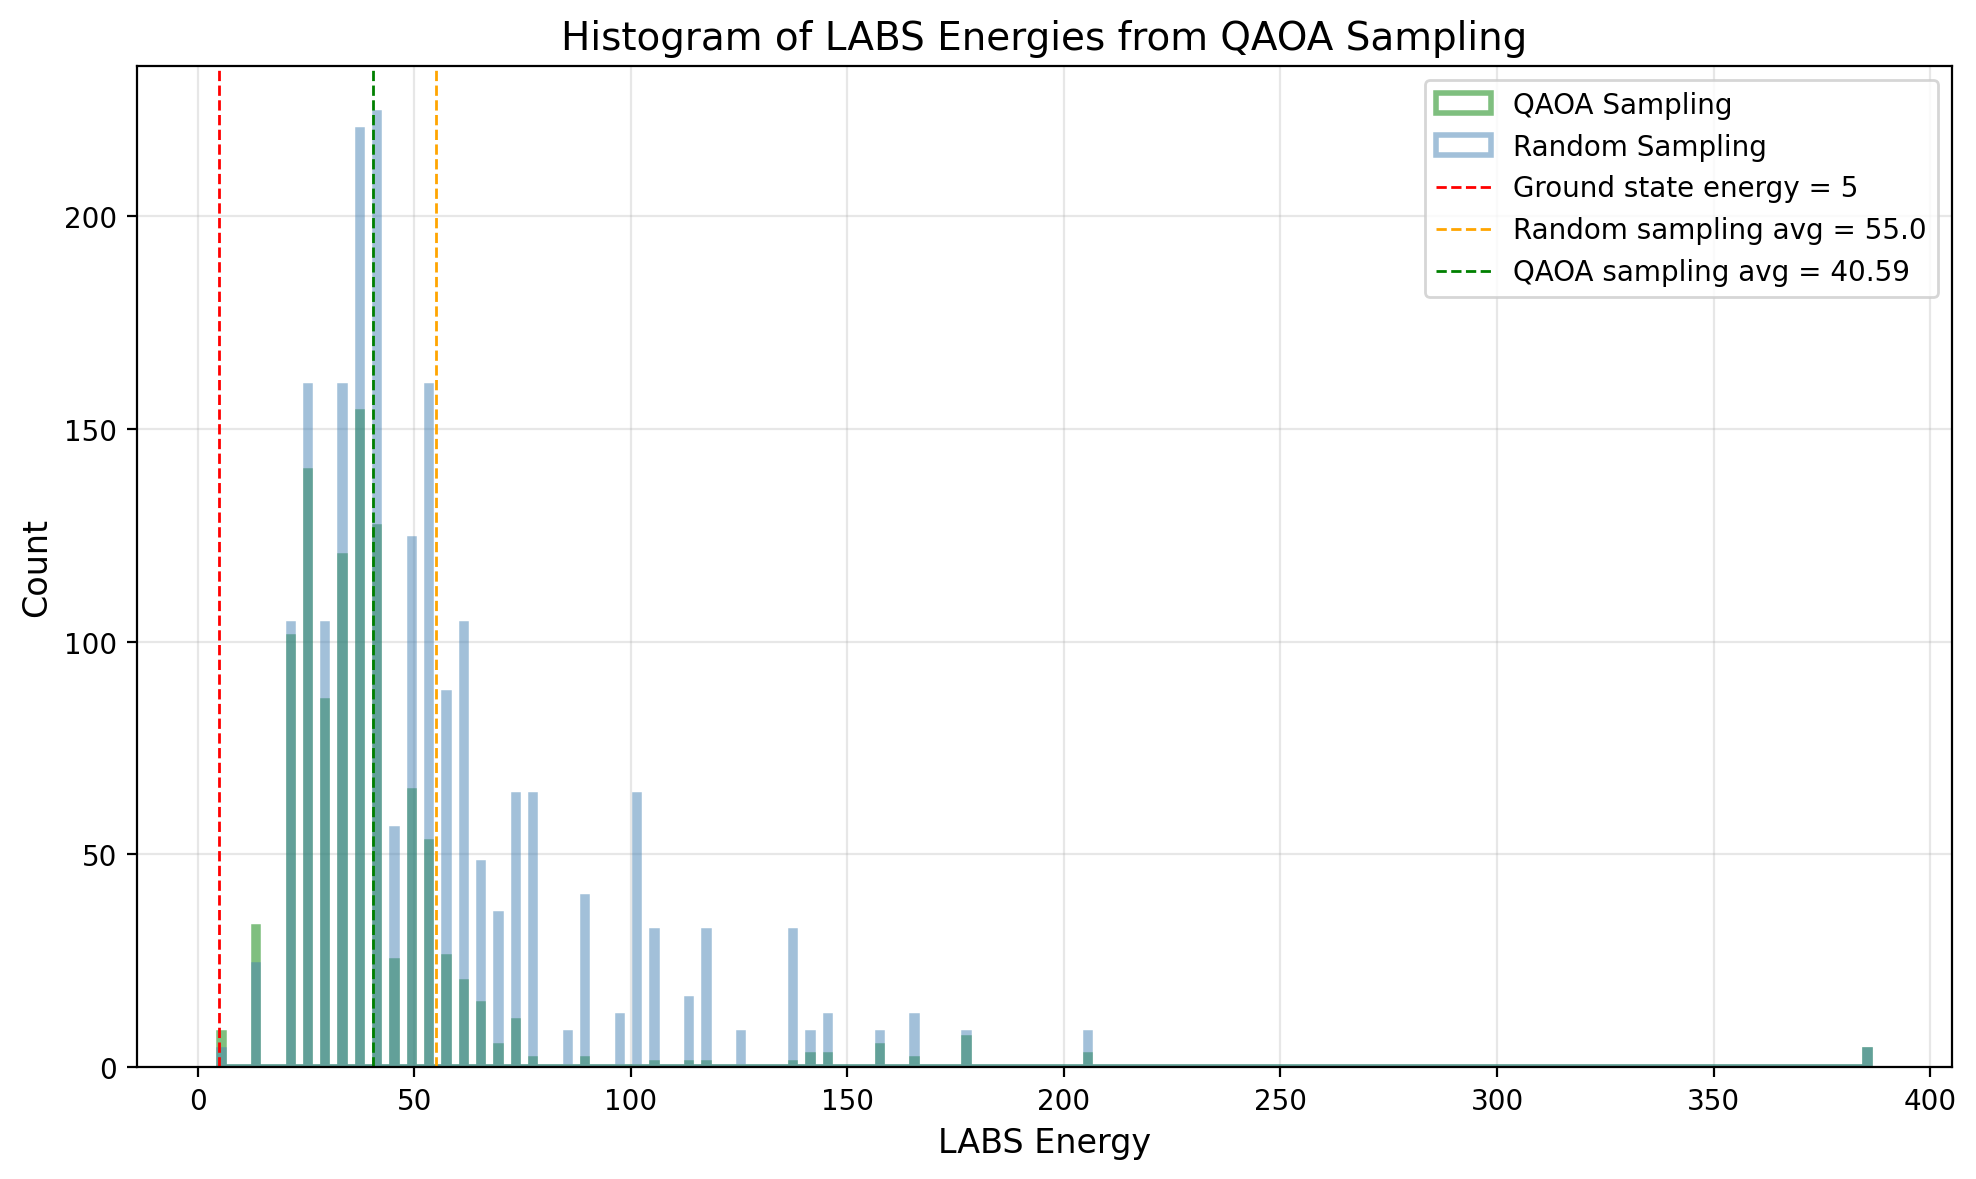

In [13]:
qaoa_sampling_energies = []
for bitstring, count in counts_bin.items():
    bit_array = np.array(list(map(int, bitstring)))
    energy = labs_energy_from_bitarray(bit_array)
    qaoa_sampling_energies.extend([energy] * count)

plt.figure(figsize=(10, 6), dpi=200)
all_energies = qaoa_sampling_energies + random_sampling_energies
bins = range(int(min(all_energies)), int(max(all_energies)) + 2)

plt.hist(
    qaoa_sampling_energies,
    bins=bins,
    histtype="step",
    alpha=0.5,
    color="green",
    edgecolor="green",
    linewidth=2,
    label="QAOA Sampling",
)
plt.hist(
    random_sampling_energies,
    bins=bins,
    histtype="step",
    alpha=0.5,
    color="steelblue",
    edgecolor="steelblue",
    linewidth=2,
    label="Random Sampling",
)
plt.axvline(
    x=min_energy,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Ground state energy = {min_energy}",
)
plt.axvline(
    x=average_energy_random_sampling,
    color="orange",
    linestyle="--",
    linewidth=1,
    label=f"Random sampling avg = {average_energy_random_sampling:.1f}",
)
plt.axvline(
    x=average_energy_qaoa_sampling,
    color="green",
    linestyle="--",
    linewidth=1,
    label=f"QAOA sampling avg = {average_energy_qaoa_sampling:.2f}",
)
plt.xlabel("LABS Energy", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Histogram of LABS Energies from QAOA Sampling", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to try next?

- Try larger $p$ to get more accurate results. 
- Try larger $N$ to see how QAOA performs for larger $N$. 
- Try BlueQubit's GPU and Pauli-Path simulators to see how QAOA performs for larger $N$.